In [1]:
import pickle
import numpy as np
import matplotlib.pyplot as plt

pkl_file = "data/topopt_20260313_160634.pkl"
with open(pkl_file, "rb") as f:
    hist = pickle.load(f)

In [2]:
for k, v in hist.items():
    if isinstance(v, np.ndarray):
        print(f"{k}: ndarray shape={v.shape}")
    elif isinstance(v, list):
        print(f"{k}: list len={len(v)}")
    else:
        print(f"{k}: {type(v).__name__} = {v}")

comp: list len=57
comp_norm: list len=57
comp_ref: float = 1309.266630204173
vol: list len=57
change: list len=57
fab_pen: list len=57
fab_tol: list len=57
beta: list len=57
x_raw: list len=57
x_proj: list len=57
x_open: list len=57
x_close: list len=57
x_phys: list len=57
params: dict = {'nelx': 180, 'nely': 90, 'volfrac': 0.35, 'rmin': 3.0, 'physics': 'elasticity', 'bc': 'mbb'}


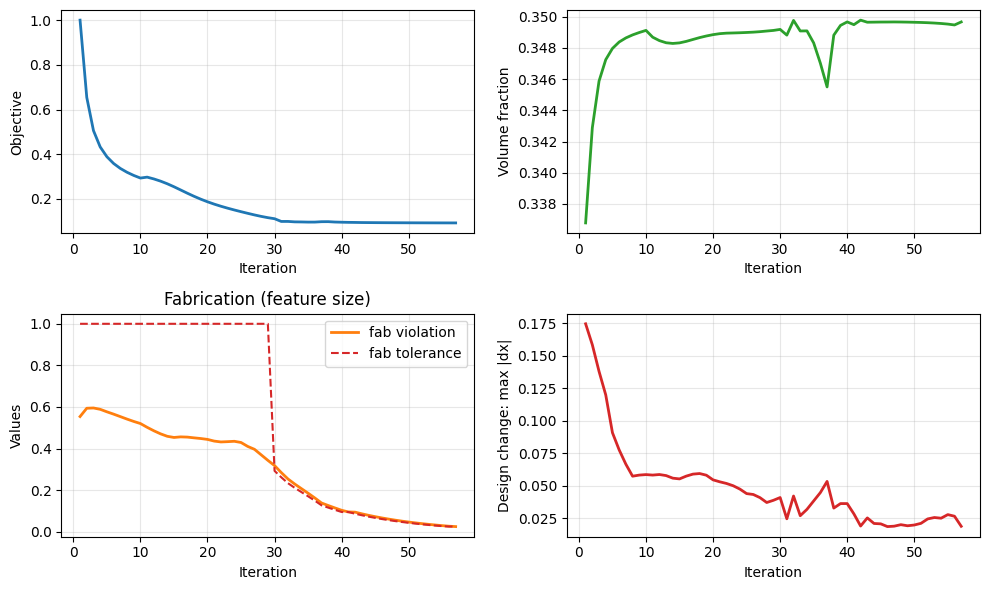

In [3]:
comp_hist = hist["comp"]
comp_norm_hist = hist["comp_norm"]
vol_hist = hist["vol"]
change_hist = hist["change"]
fab_pen_hist = hist["fab_pen"]
fab_tol_hist = hist["fab_tol"]
vol = hist["vol"]
iters = np.arange(1, len(comp_hist) + 1)

fig_conv, axs_conv = plt.subplots(2, 2, figsize=(10, 6))

axs_conv[0, 0].plot(iters, comp_norm_hist, color="tab:blue", linewidth=2.0)
axs_conv[0, 0].set_xlabel("Iteration")
axs_conv[0, 0].set_ylabel("Objective")
axs_conv[0, 0].grid(True, alpha=0.3)

axs_conv[0, 1].plot(iters, vol_hist, color="tab:green", linewidth=2.0)
axs_conv[0, 1].set_xlabel("Iteration")
axs_conv[0, 1].set_ylabel("Volume fraction")
axs_conv[0, 1].grid(True, alpha=0.3)

axs_conv[1, 0].plot(iters, fab_pen_hist, color="tab:orange", linewidth=2.0, label="fab violation")
axs_conv[1, 0].plot(iters, fab_tol_hist, color="tab:red", linestyle="--", linewidth=1.5, label="fab tolerance")
axs_conv[1, 0].set_title("Fabrication (feature size)")
axs_conv[1, 0].set_xlabel("Iteration")
axs_conv[1, 0].set_ylabel("Values")
axs_conv[1, 0].grid(True, alpha=0.3)
axs_conv[1, 0].legend()

axs_conv[1, 1].plot(iters, change_hist, color="tab:red", linewidth=2.0)
axs_conv[1, 1].set_xlabel("Iteration")
axs_conv[1, 1].set_ylabel("Design change: max |dx|")
axs_conv[1, 1].grid(True, alpha=0.3)
fig_conv.tight_layout()
plt.show()

In [24]:
import os
from PIL import Image
from pathlib import Path

timestamp = Path(pkl_file).stem
frame_dir = f"data/{timestamp}_frames"
os.makedirs(frame_dir, exist_ok=True)

x_phys_all = np.array(hist["x_phys"])  # (n_iters, nely, nelx)

# Save each frame as PNG
frame_paths = []
for i, x in enumerate(x_phys_all):
    fig, ax = plt.subplots()
    ax.imshow(1.0 - x, interpolation="none", origin="upper", cmap="gray", vmin=0, vmax=1)
    ax.set_title(f"Iteration {i+1}")
    ax.axis("off")
    fp = f"{frame_dir}/frame_{i:04d}.png"
    plt.savefig(fp, bbox_inches="tight", pad_inches=0, dpi=150)
    plt.close(fig)
    frame_paths.append(fp)

# Assemble GIF
frames = [Image.open(p) for p in frame_paths]
gif_path = f"{frame_dir}/{timestamp}.gif"
durations = [150] * len(frames)
durations[-1] = 1500  # last frame stays 1 second before looping
frames[0].save(gif_path, save_all=True, append_images=frames[1:],
               duration=durations, loop=0)
print(f"Saved GIF: {gif_path} ({len(frames)} frames)")

Saved GIF: data/topopt_20260313_161330_frames/topopt_20260313_161330.gif (53 frames)
